# ライブラリのインストール

In [35]:
import sys
import os
import importlib

# ディレクトリ情報取得

In [ ]:
current_dir = os.getcwd()
python_root = current_dir
if not os.path.isdir(os.path.join(python_root, 'source')):
    parent_dir = os.path.dirname(current_dir)
    if os.path.isdir(os.path.join(parent_dir, 'source')):
        python_root = parent_dir
    else:
        candidate = os.path.join(current_dir, 'population_job', 'python')
        if os.path.isdir(os.path.join(candidate, 'source')):
            python_root = candidate

if python_root not in sys.path:
    sys.path.insert(0, python_root)

print(f"現在のディレクトリ: {current_dir}")
print(f"python root: {python_root}")
print(f"Python実行ファイル: {sys.executable}")

現在のディレクトリ: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\notebook
python root: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python
Python実行ファイル: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\.venv\Scripts\python.exe


# 自作ライブラリのインストール

In [65]:
# 再実行時にソースを更新した場合でも反映するため、すでに読み込まれているモジュールはreloadする。
def reload_or_import(module_name):
    if module_name in sys.modules:
        return importlib.reload(sys.modules[module_name])
    return importlib.import_module(module_name)

# ConnectDB.pyからFetch_data関数をインポート
try:
    reload_or_import("source.mylib.ConnectDB")
    from source.mylib.ConnectDB import *
    print("✓ source/mylib/ConnectDB.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

# MakeOutput.pyから関数をインポート
try:
    reload_or_import("source.mylib.MakeOutput")
    from source.mylib.MakeOutput import *
    print("✓ source/mylib/MakeOutput.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

# ReadWriteData.pyから関数をインポート
try:
    reload_or_import("source.mylib.ReadWriteData")
    from source.mylib.ReadWriteData import *
    print("✓ source/mylib/ReadWriteData.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

# Preprocessing.pyから関数をインポート
try:
    reload_or_import("source.mylib.Preprocessing")
    from source.mylib.Preprocessing import *
    print("✓ source/mylib/Preprocessing.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

# ExtractDataFrame.pyから関数をインポート
try:
    reload_or_import("source.mylib.ExtractDataFrame")
    from source.mylib.ExtractDataFrame import *
    print("✓ source/mylib/ExtractDataFrame.py のインポートに成功しました")
except ImportError as e:
    print(f"✗ インポートエラー: {e}")
except Exception as e:
    print(f"✗ エラー: {e}")

✓ source/mylib/ConnectDB.py のインポートに成功しました
✓ source/mylib/MakeOutput.py のインポートに成功しました
✓ source/mylib/ReadWriteData.py のインポートに成功しました
✓ source/mylib/Preprocessing.py のインポートに成功しました
✓ source/mylib/ExtractDataFrame.py のインポートに成功しました


# テーブル内容取得

dataフォルダにcsvファイルが存在する場合はそれを取得、存在しない場合はSQLDBに接続して内容を取得

## configファイルのパス指定

In [3]:
# データベースへの接続文字列をconfigファイルから読み込む。
config_path = os.path.join(python_root, 'config', 'connect_DB.config')
print(f"configファイルのパス: {config_path}")

configファイルのパス: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\config\connect_DB.config


## dataフォルダのパス指定

In [4]:
data_dir = os.path.join(python_root, 'data')
print(f"dataディレクトリのパス: {data_dir}")

dataディレクトリのパス: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\data


## dataディレクトリにcsvファイルが存在するかどうかの確認

### データを一括管理するための辞書を作成

In [5]:
data_dict ={}

### データを取得
取得データは以下の通り  
- economic_census_employments：経済センサス（都道府県×業種×性別での就業者数）テーブル
- economic_census_code：経済センサス（都道府県×業種×性別での就業者数）テーブルの産業コードのコード値対応表
- laborforce_generation_industry_employ：労働力調査（全国の総就業者数）テーブル
- laborforce_generation_industry_employ_codes：労働力調査（全国の総就業者数）テーブルの産業コードのコード値対応表
- prefecture_metadata_codes：都道府県コードのコード値対応表
- sex_metadata_codes：性別コードのコード値対応表
- generation_metadata_codes：年代コードのコード値対応表

In [6]:
# データ名のリスト
data_name_list = [
    'economic_census_employments', 
    'economic_census_code', 
    'laborforce_generation_industry_employ', 
    'laborforce_generation_industry_employ_codes', 
    'prefecture_metadata_codes', 
    'sex_metadata_codes', 
    'generation_metadata_codes',
    ]

# データ名のリストをループして、data_dictにデータと列名、行数を追加
for data_name in data_name_list:
    Add_data_to_dict(data_dict, data_name, data_dir, config_path)
    data_dict[f'{data_name}_columns'], data_dict[f'{data_name}_number_of_rows'] = Check_df(data_dict[f'{data_name}_df'])

✓ ファイルが存在します: c:\Users\hanju\OneDrive\デスクトップ\学習\SS\population_job\python\data\economic_census_employments.csv
✓ ファイル取得完了
データフレームの冒頭5行を表示
   prefecture_code  year  industry_code  employments_total_t  \
0                0  2012              2           55837252.0   
1                0  2012             51            1627310.0   
2                0  2012             52             196034.0   
3                0  2012             53              68217.0   
4                0  2012             54            1044779.0   

   employments_total_m  employments_total_f               updated_at  
0           31355187.0           24302231.0  2026-04-19 01:48:42.653  
1            1192715.0             410999.0  2026-04-19 01:48:42.653  
2             128186.0              46354.0  2026-04-19 01:48:42.653  
3              48981.0              19146.0  2026-04-19 01:48:42.653  
4             801926.0             241924.0  2026-04-19 01:48:42.653  
データフレームのカラム一覧、カラム数、列数を表示
カラム一覧: ['prefecture_code', 

### テーブル名と可視化結果の命名の対応辞書作成

In [25]:
name_dict = {
    'economic_census_employments': '経済センサス（就業者数）',
    'economic_census_code': '産業コード（経済センサス）',
    'laborforce_generation_industry_employ': '労働力調査（就業者数）',
    'laborforce_generation_industry_employ_codes': '産業コード（労働力調査）',
    'prefecture_metadata_codes': '都道府県コード',
    'sex_metadata_codes': '性別コード',
    'generation_metadata_codes': '世代コード',
}


## 元データ時点での可視化

### laborforce_generation_industry_employ

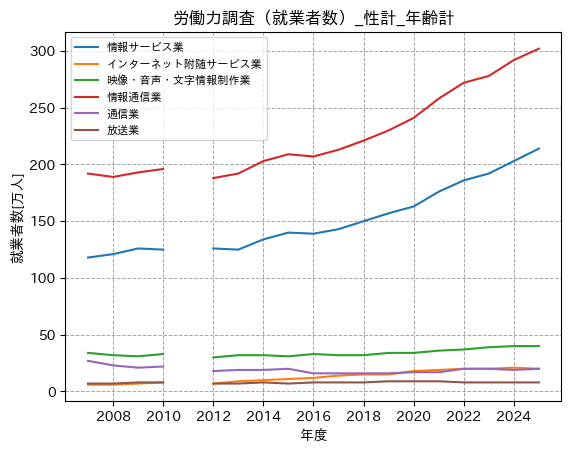

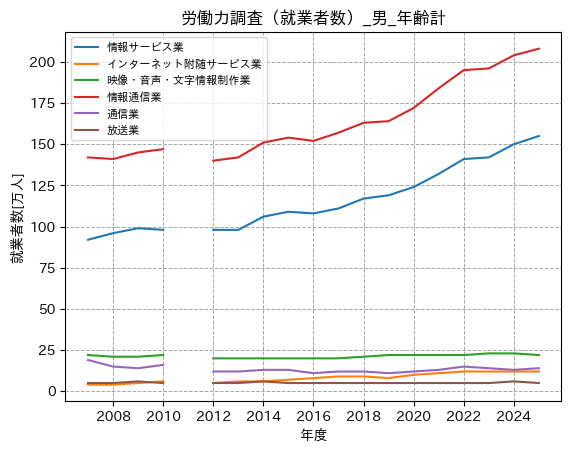

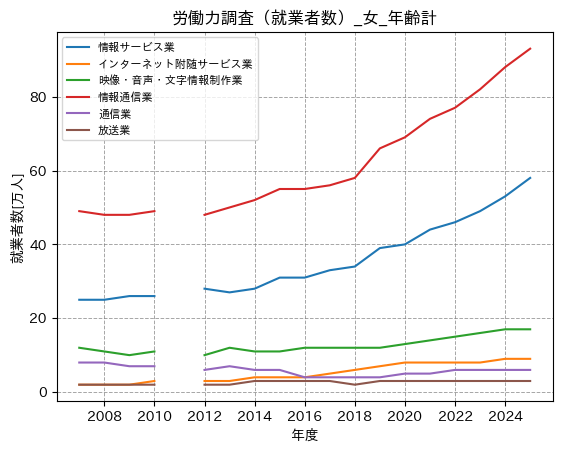

In [45]:
data_name = 'laborforce_generation_industry_employ'

generation = '年齢計' 
generation_code = Content_to_code(data_dict['generation_metadata_codes_df'], 'generation', generation, 'generation_code')

sex_list = ['性計', '男', '女']
for sex in sex_list:
    sex_code = Content_to_code(data_dict['sex_metadata_codes_df'], 'sex', sex, 'sex_code')

    x_dict = {}
    y_dict = {}

    industry_list = ['情報サービス業', 'インターネット附随サービス業', '映像・音声・文字情報制作業', '情報通信業', '通信業', '放送業']
    for industry in industry_list:
        industry_code = Content_to_code(data_dict[f'{data_name}_codes_df'], 'industry_name', industry, 'industry_code')

        df_extract = data_dict[f'{data_name}_df']
        df_extract = df_extract[df_extract['sex_code'] == sex_code]
        df_extract = df_extract[df_extract['generation_code'] == generation_code]
        df_extract = df_extract[['sex_code', 'generation_code', 'year', f'job_{industry_code}']]
        x_dict[f'{industry}'] = [int(year) for year in df_extract['year']]
        y_dict[f'{industry}'] = df_extract[f'job_{industry_code}']

    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{generation}.png')
    Make_line_plot(
        x_dict, 
        y_dict, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{generation}', 
        xlabel='年度', 
        ylabel='就業者数[万人]', 
        path=fig_path
    )


### economic_census_employments

In [ ]:
year_list = sorted([int(year) for year in data_dict['economic_census_employments_df']['year'].unique()])
print(year_list)

[2012, 2016, 2021]


In [40]:
data_dict['economic_census_employments_df']

,prefecture_code,year,industry_code,employments_total_t,employments_total_m,employments_total_f,updated_at
0,0,2012,2,55837252.0,31355187.0,24302231.0,2026-04-19 01:48:42.653
1,0,2012,51,1627310.0,1192715.0,410999.0,2026-04-19 01:48:42.653
2,0,2012,52,196034.0,128186.0,46354.0,2026-04-19 01:48:42.653
3,0,2012,53,68217.0,48981.0,19146.0,2026-04-19 01:48:42.653
4,0,2012,54,1044779.0,801926.0,241924.0,2026-04-19 01:48:42.653
...,...,...,...,...,...,...,...
1291,47,2021,54,8132.0,5465.0,2611.0,2026-04-19 02:05:36.623
1292,47,2021,55,2254.0,1175.0,1079.0,2026-04-19 02:05:36.623
1293,47,2021,56,1723.0,1137.0,582.0,2026-04-19 02:05:36.623
1294,47,2021,57,3753.0,2368.0,1380.0,2026-04-19 02:05:36.623


In [41]:
data_dict['prefecture_metadata_codes_df']

,prefecture_code,prefecture_name,region_code,region_type
0,0,全国,0,全国
1,1,北海道,1,都道府県
2,2,青森県,1,都道府県
3,3,岩手県,1,都道府県
4,4,宮城県,1,都道府県
...,...,...,...,...
66,66,岡山市,2,政令市、23区
67,67,広島市,2,政令市、23区
68,68,北九州市,2,政令市、23区
69,69,福岡市,2,政令市、23区


In [42]:
data_dict['economic_census_employments_df']['industry_code'].unique()

array([ 2, 51, 52, 53, 54, 55, 56, 57, 58])

In [50]:
data_dict['economic_census_code_df']

,job_code,job_name_2012,job_name_2016,job_name_2021
0,1,該当なし,該当なし,全産業
1,2,A～R全産業（Ｓ公務を除く）,A～R全産業（Ｓ公務を除く）,全産業（S_公務を除く）
2,3,A～B農林漁業,A～B農林漁業,農林漁業
3,4,A農業，林業,A農業，林業,農業，林業
4,5,01農業,01農業,農業
...,...,...,...,...
138,139,92その他の事業サービス業,92その他の事業サービス業,その他の事業サービス業
139,140,95その他のサービス業,95その他のサービス業,その他のサービス業
140,141,該当なし,該当なし,公務（他に分類されるものを除く）
141,142,該当なし,該当なし,国家公務


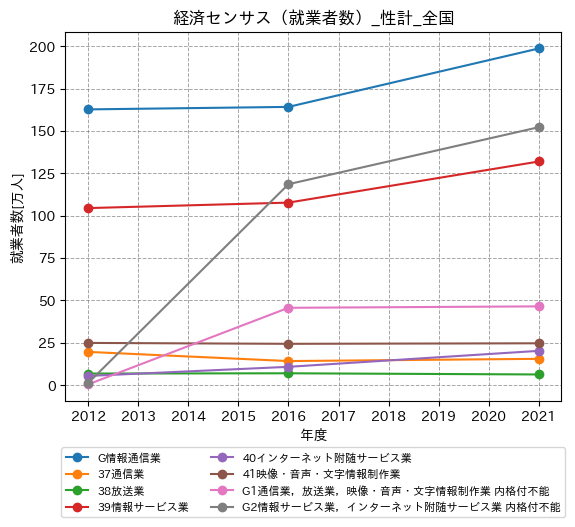

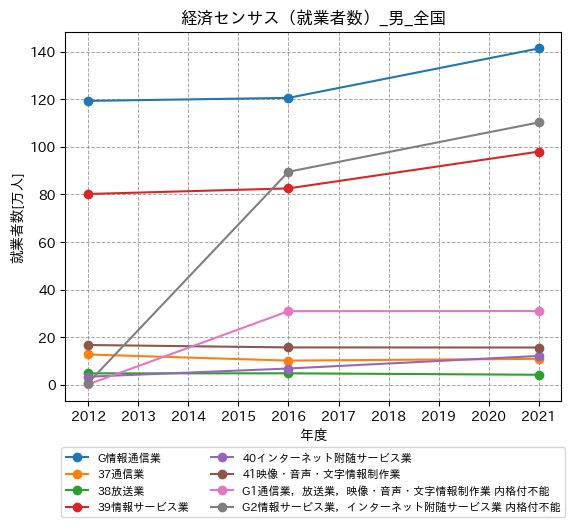

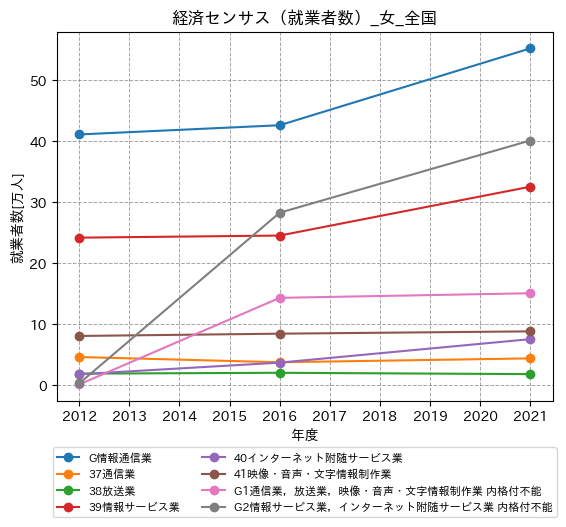

In [66]:
data_name = 'economic_census_employments'

prefecture = '全国' 
prefecture_code = Content_to_code(data_dict['prefecture_metadata_codes_df'], 'prefecture_name', prefecture, 'prefecture_code')

sex_list = ['性計', '男', '女']
for sex in sex_list:
    if sex == '性計':
        suffix = 't'
    elif sex == '男':
        suffix = 'm'
    elif sex == '女':
        suffix = 'f'

    x_dict = {}
    y_dict = {}

    industry_code_list = [51, 52, 53, 54, 55, 56, 57, 58]
    for industry_code in industry_code_list:
        industry = Code_to_content(data_dict['economic_census_code_df'], 'job_code', industry_code, 'job_name_2012')

        df_extract = data_dict[f'{data_name}_df']
        df_extract = df_extract[df_extract['prefecture_code'] == prefecture_code]
        df_extract = df_extract[df_extract['industry_code'] == industry_code]
        df_extract = df_extract[['prefecture_code', 'year', 'industry_code', f'employments_total_{suffix}']]
        x_dict[f'{industry}'] = [int(year) for year in df_extract['year']]
        y_dict[f'{industry}'] = [employments / 10000 for employments in df_extract[f'employments_total_{suffix}']]

    fig_path = os.path.join(python_root, 'output', 'img', f'line_plot_{name_dict[data_name]}_{sex}_{prefecture}.png')
    Make_line_plot(
        x_dict, 
        y_dict, 
        x_integer=True, 
        y_integer=False, 
        x_lim=None, 
        y_lim=None, 
        title=f'{name_dict[data_name]}_{sex}_{prefecture}', 
        xlabel='年度', 
        ylabel='就業者数[万人]', 
        legend_bottom=True,
        path=fig_path
    )
